# NASA Near-Earth Asteroid Analysis

## Project Overview

This project uses NASA's Near-Earth Object (NEO) API to analyze asteroids approaching Earth. The analysis explores asteroid size, miss distance, hazardous classification, and upcoming close approaches through a series of interactive visualizations.

In [4]:
import prettytable
import pandas as pd
import sqlite3 as sql3
import requests
import plotly.express as px
import datetime as dt

from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv("API_KEY")

In [5]:
prettytable.DEFAULT = 'DEFAULT'

conn = sql3.connect("AsteroidDB.db")
cursor = conn.cursor()

%load_ext sql

current = dt.datetime.now()
to_date = current + dt.timedelta(days=6)
current_str = dt.datetime.now().strftime("%Y-%m-%d")
to_str = to_date.strftime("%Y-%m-%d")

## DATA COLLECTION

Using NASA's Near-Earth Object (NEO) API, I collected data on asteroids approaching Earth. The dataset includes the asteroid's name, minimum and maximum estimated diameter in feet, hazardous classification, close approach date and time, and miss distance in miles. This information was extracted from the API's JSON response and stored in a Pandas DataFrame for further analysis.


In [7]:
api_key = 'YyIyPcf4iQORkZfTv7DFdaZw7KqSQ6KlSSeso2Zq'
url = f"https://api.nasa.gov/neo/rest/v1/feed?start_date={current_str}&end_date={to_str}&api_key={API_KEY}"

response = requests.get(url)
data = response.json()
ob_data = data['near_earth_objects']

In [8]:
rows = []

for item in ob_data:
    for asteroid in ob_data[item]:
        rows.append({
            "Name": asteroid["name"].split("(")[1].rstrip(")"),
            "Min Diameter (feet)": round(
                asteroid["estimated_diameter"]["feet"]["estimated_diameter_min"], 2
            ),
            "Max Diameter (feet)": round(
                asteroid["estimated_diameter"]["feet"]["estimated_diameter_max"], 2
            ),
            "Hazardous": asteroid["is_potentially_hazardous_asteroid"],
            "Close Approach Date": pd.to_datetime(
                asteroid["close_approach_data"][0]["close_approach_date_full"]
            ),
            "Miss Distance (miles)": round(
                float(
                    asteroid["close_approach_data"][0]["miss_distance"]["miles"]
                ),
                2,
            ),
        })

asteroid_data = pd.DataFrame(rows)
asteroid_data.dropna(inplace=True)

## DATA CLEANING

The data returned by NASA's API was provided in a nested JSON format and required preprocessing before analysis. Relevant fields were extracted, including asteroid name, estimated diameter, hazardous classification, close approach date, and miss distance. The data was then organized into a Pandas DataFrame, converted to appropriate data types, and reviewed for missing or inconsistent values to ensure accuracy prior to loading it into the database.

In [10]:
asteroid_data = pd.DataFrame(columns=['Name', 'Min Diameter (feet)', 'Max Diameter (feet)', 'Hazardous', 'Close Approach Date', 'Miss Distance (miles)'])

for item in ob_data:
    for i, ob in enumerate(ob_data[item]):
        name = ob_data[item][i]['name'].split("(")[1].rstrip(")")
        min_diameter = round(ob_data[item][i]['estimated_diameter']['feet']['estimated_diameter_min'],2)
        max_diameter = round(ob_data[item][i]['estimated_diameter']['feet']['estimated_diameter_max'],2)
        is_hazardous = ob_data[item][i]['is_potentially_hazardous_asteroid']
        close_approach_date = pd.to_datetime(ob_data[item][i]['close_approach_data'][0]['close_approach_date_full'])
        miss_distance = round(float(ob_data[item][i]['close_approach_data'][0]['miss_distance']['miles']),2)
        asteroid_data = pd.concat([asteroid_data,pd.DataFrame({'Name':[name],
                                                             'Min Diameter (feet)':[min_diameter], 
                                                             'Max Diameter (feet)':[max_diameter],
                                                             'Hazardous':[is_hazardous],
                                                             'Close Approach Date':[close_approach_date],
                                                             'Miss Distance (miles)':[miss_distance]})], ignore_index=True)

asteroid_data.dropna(inplace=True)

/var/folders/7t/qdrpzfbn3ld1sbslt8yr_v600000gn/T/ipykernel_57619/1303468376.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  asteroid_data = pd.concat([asteroid_data,pd.DataFrame({'Name':[name],


## DATABASE CREATION

After cleaning and organizing the asteroid data in a Pandas DataFrame, the dataset was loaded into a SQLite database. Storing the data in a relational database enabled the performance of SQL queries, calculation of summary statistics, filtering of records, and identification of patterns within the dataset. The database serves as a structured and reusable source for analysis and visualization.

In [12]:
asteroid_data.to_sql("ASTEROID_IMPACT_DATA", conn, if_exists='replace', index=False, method='multi');
%sql sqlite:///AsteroidDB.db

## SQL ANALYSIS
### Asteroids Approaching Earth Within the Next Seven Days

In [14]:
%sql select * from ASTEROID_IMPACT_DATA order by "Close Approach Date" asc;

 * sqlite:///AsteroidDB.db
Done.


Name,Min Diameter (feet),Max Diameter (feet),Hazardous,Close Approach Date,Miss Distance (miles)
2018 GE2,34.08,76.21,0,2026-06-25 00:47:00,27473864.42
2013 KF6,479.23,1071.58,0,2026-06-25 02:48:00,40281743.57
2018 CP2,120.38,269.17,0,2026-06-25 02:54:00,13389838.84
2016 VK,275.77,616.63,0,2026-06-25 03:15:00,14083028.83
2010 WU8,126.05,281.85,0,2026-06-25 13:26:00,20110859.55
2018 MJ7,203.49,455.01,0,2026-06-25 15:59:00,12812740.67
2022 CL12,216.04,483.09,0,2026-06-25 16:10:00,45106588.55
2016 LS68,316.62,707.99,0,2026-06-25 21:47:00,45927243.22
2014 MR67,240.18,537.06,0,2026-06-26 01:18:00,22939121.0
2016 TA57,606.09,1355.27,1,2026-06-26 03:08:00,43460124.48


In [15]:
%sql select *, CASE when hazardous = 1 then 'True' else 'false' end as hazardous from ASTEROID_IMPACT_DATA;

 * sqlite:///AsteroidDB.db
Done.


Name,Min Diameter (feet),Max Diameter (feet),Hazardous,Close Approach Date,Miss Distance (miles),hazardous
2010 WU8,126.05,281.85,0,2026-06-25 13:26:00,20110859.55,false
2013 KF6,479.23,1071.58,0,2026-06-25 02:48:00,40281743.57,false
2016 LS68,316.62,707.99,0,2026-06-25 21:47:00,45927243.22,false
2016 VK,275.77,616.63,0,2026-06-25 03:15:00,14083028.83,false
2018 CP2,120.38,269.17,0,2026-06-25 02:54:00,13389838.84,false
2018 GE2,34.08,76.21,0,2026-06-25 00:47:00,27473864.42,false
2018 MJ7,203.49,455.01,0,2026-06-25 15:59:00,12812740.67,false
2022 CL12,216.04,483.09,0,2026-06-25 16:10:00,45106588.55,false
2010 LE15,1187.24,2654.76,1,2026-06-30 07:30:00,17778552.8,True
2016 AR130,712.1,1592.3,0,2026-06-30 15:06:00,33627085.7,false


### Potentially Hazardous Asteroids

In [17]:
%sql select name, date([Close Approach Date]) as "Approach Date", time([Close Approach Date]) \
as "Approach Time", "miss distance (miles)" from ASTEROID_IMPACT_DATA where hazardous = true group by name;

 * sqlite:///AsteroidDB.db
Done.


Name,Approach Date,Approach Time,Miss Distance (miles)
1997 NC1,2026-06-27,11:16:00,1594339.29
2010 LE15,2026-06-30,07:30:00,17778552.8
2010 NY65,2026-07-01,12:42:00,16982065.79
2016 TA57,2026-06-26,03:08:00,43460124.48


### Top 10 Closest Asteroid Approaches

In [19]:
%sql select name, printf('%.2f', "miss distance (miles)", 2) as "Miss Distance", date([Close Approach Date]) \
as "Approach Date", time([Close Approach Date]) as "Approach Time", case when hazardous = 1 \
then 'true' else 'false' end as hazardous from ASTEROID_IMPACT_DATA \
order by [miss distance (miles)] asc limit 10;

 * sqlite:///AsteroidDB.db
Done.


Name,Miss Distance,Approach Date,Approach Time,hazardous
1997 NC1,1594339.29,2026-06-27,11:16:00,true
2014 NV63,5200490.76,2026-06-26,05:35:00,false
2019 NG,8477543.54,2026-06-27,07:43:00,false
2016 XR23,8603920.33,2026-06-27,23:07:00,false
2005 NE21,8974240.68,2026-07-01,08:41:00,false
2018 NV,9381718.60,2026-06-26,13:43:00,false
2002 EM7,10514902.62,2026-06-26,15:53:00,false
2018 MJ7,12812740.67,2026-06-25,15:59:00,false
2018 CP2,13389838.84,2026-06-25,02:54:00,false
2016 VK,14083028.83,2026-06-25,03:15:00,false


### Largest Asteroids by Maximum Diameter

In [21]:
%sql select name, printf('%.2f', [Max Diameter (feet)]) as [Maximum Diameter by Feet], \
CASE when Hazardous = 1 THEN 'true' ELSE 'false' end as Hazardous from ASTEROID_IMPACT_DATA order by [Max Diameter (feet)] desc \
limit 10;  

 * sqlite:///AsteroidDB.db
Done.


Name,Maximum Diameter by Feet,Hazardous
1997 NC1,5200.26,true
2010 LE15,2654.76,true
2004 RH340,2421.17,false
2014 XQ3,2366.06,false
2015 VH66,1923.20,false
2015 MO66,1862.19,false
2016 JH17,1682.77,false
2016 AR130,1592.30,false
2018 LW5,1438.88,false
2016 TA57,1355.27,true


### Average Miss Distance by Hazard Classification

In [23]:
%sql select printf('%.2f', round(avg([Miss Distance (miles)]), 2)) AS [Average Miss Distance by Feet] from ASTEROID_IMPACT_DATA;

 * sqlite:///AsteroidDB.db
Done.


Average Miss Distance by Feet
25591650.61


### Average Maximum and Minimum Diameter

In [25]:
%sql select round(avg([Max Diameter (feet)]), 2) as "Average Max Diameter (feet)", printf('%.2f', round(avg([Min Diameter (feet)]), 2)) as "Average Min Diameter (feet)" from ASTEROID_IMPACT_DATA;

 * sqlite:///AsteroidDB.db
Done.


Average Max Diameter (feet),Average Min Diameter (feet)
945.57,422.87


## Visualizations (Based on the next 7 days)

### Relationship Between Asteroid Size and Miss Distance
This scatter plot visualizes the relationship between asteroid size and the distance from Earth at which it would miss. Asteroids are color-coded according to their hazardous classification, enabling easy identification of potentially hazardous objects.

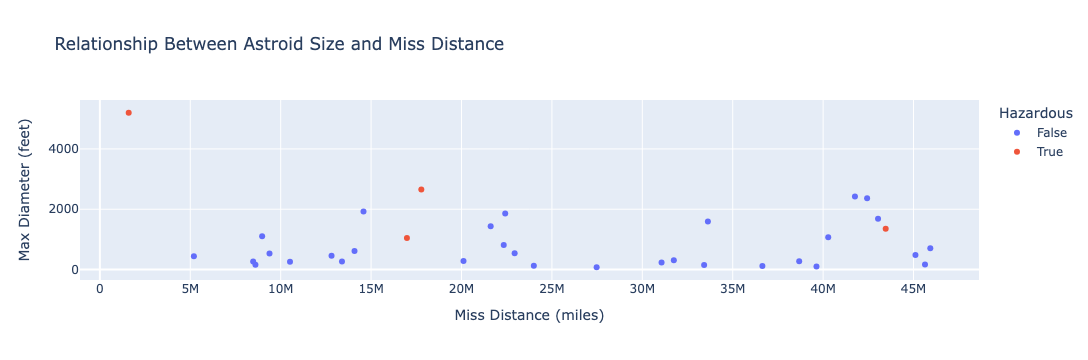

In [54]:
fig_asteroid_miss_distance = px.scatter(
    asteroid_data,
    x = 'Miss Distance (miles)',
    y = 'Max Diameter (feet)',
    color= 'Hazardous',
    title = 'Relationship Between Astroid Size and Miss Distance'
)
fig_asteroid_miss_distance.show()

### Distribution of Asteroid Sizes
This histogram displays the distribution of asteroid maximum diameters measured in feet. It highlights the frequency of asteroids across different size categories, providing insight into the overall size distribution of the observed objects.

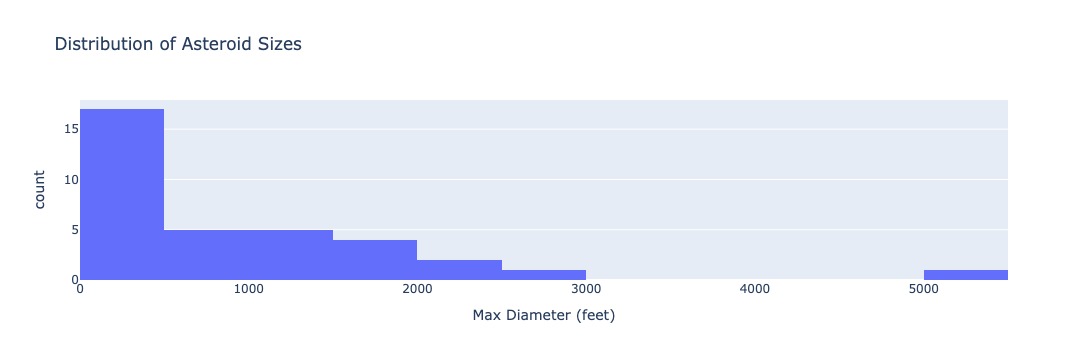

In [29]:
fig_asteroid_sizes = px.histogram(
    asteroid_data,
    x= 'Max Diameter (feet)',
    title= 'Distribution of Asteroid Sizes'
)
fig_asteroid_sizes.show()

### Hazardous vs Non-Hazardous Asteroids
This bar chart visualizes the distribution of the Boolean variable "Hazardous," showing the number of asteroids categorized as either hazardous (True) or non-hazardous (False).

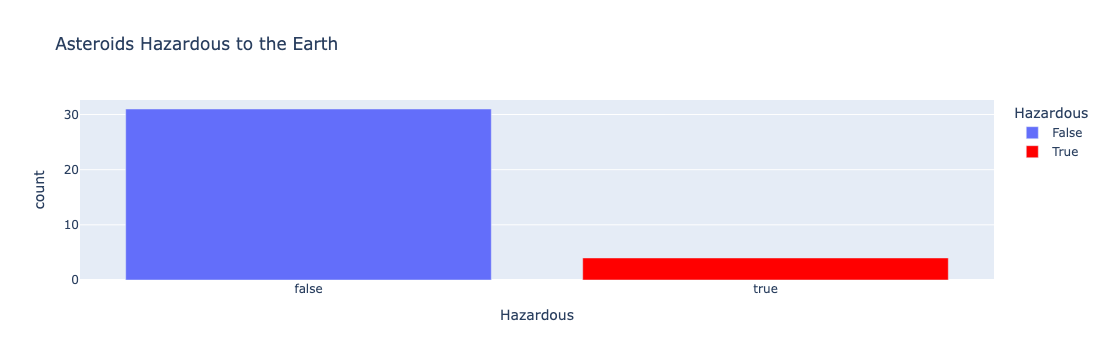

In [31]:
haz_counts = asteroid_data['Hazardous'].value_counts().reset_index()
fig_asteroid_hazard = px.bar(
    haz_counts,
    x = 'Hazardous',
    y = 'count',
    color='Hazardous',
    color_discrete_map={
        True: 'red',
        False: '#636EFA'
    },
    title = 'Asteroids Hazardous to the Earth'
)
fig_asteroid_hazard.show()

### Asteroid Close Approach Timeline (3 Day Forecast)
This scatter plot visualizes the close approach timeline of asteroids over the next three days. The color of each point indicates whether the asteroid is classified as hazardous or non-hazardous.

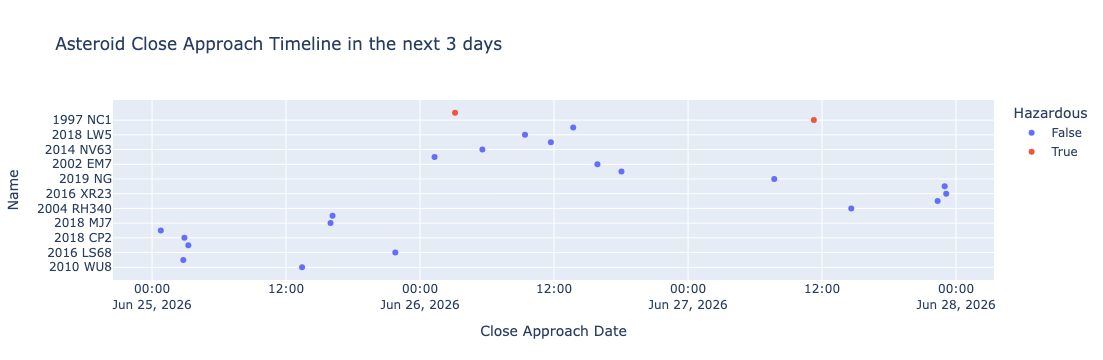

In [33]:
today = dt.datetime.now().date()
end_date = today + dt.timedelta(days=2)

asteroid_data['Close Approach Date'] = pd.to_datetime(
    asteroid_data['Close Approach Date']
)

upcoming = asteroid_data[
    (asteroid_data['Close Approach Date'].dt.date >= today) &
    (asteroid_data['Close Approach Date'].dt.date <= end_date)
]

fig = px.scatter(
    upcoming,
    x='Close Approach Date',
    y='Name',
    color='Hazardous',
    hover_data=['Max Diameter (feet)', 'Miss Distance (miles)'],
    title='Asteroid Close Approach Timeline in the next 3 days'
)

fig.show()

## Key Findings

- Most asteroids in the dataset are classified as non-hazardous.
- Asteroid sizes vary significantly, with most objects concentrated in smaller size ranges.
- Hazardous asteroids are relatively uncommon compared to the total population.
- Several named asteroids are scheduled to make close approaches within the next three days.

## CONCLUSION
This project demonstrated how data can be collected from a public API, cleaned and transformed using Pandas, stored in a SQLite database, analyzed with SQL, and visualized through charts. The project provided insight into how NASA tracks near-Earth objects and assesses potential threats to Earth.

Future improvements could include automating daily data collection, expanding the observation period, tracking asteroids over time, and incorporating orbital data to visualize asteroid trajectories relative to Earth. Additional analysis could also explore trends in asteroid size, frequency of close approaches, and hazardous classifications over longer periods.
